# Phase 2 — FAISS Indexing & Retrieval

Replaces the brute-force numpy cosine search from Phase 1 with a FAISS `IndexFlatIP` (inner-product) index.
Because all CLIP embeddings are already L2-normalised, inner-product == cosine similarity.

The index is built from the **clean embedding set** produced in Phase 0, which has already removed
non-photographic images (architectural diagrams, floor plans, 3D renders) using a CLIP-based
zero-shot photo filter. This ensures retrieval operates only over real landmark photographs.

**Pipeline:** sketch (+ optional text) → CLIP → fused query → FAISS over clean index → metadata-enriched results

In [16]:
# Install all dependencies in one cell.
# Run this once, then restart the kernel before continuing.
%pip install faiss-cpu torch torchvision ftfy regex tqdm clip-anytorch matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [17]:
# ── Environment guards ────────────────────────────────────────────────────────
# These must be set BEFORE importing any native library (FAISS, PyTorch, NumPy).
# They prevent OpenMP from spawning competing thread pools which crash on macOS ARM64.
import os
os.environ["OMP_NUM_THREADS"]             = "1"
os.environ["MKL_NUM_THREADS"]             = "1"
os.environ["VECLIB_MAXIMUM_THREADS"]      = "1"
os.environ["NUMEXPR_NUM_THREADS"]         = "1"
os.environ["KMP_DUPLICATE_LIB_OK"]        = "TRUE"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["TOKENIZERS_PARALLELISM"]      = "false"
os.environ["KMP_INIT_AT_FORK"]            = "FALSE"

import csv, pickle
import numpy as np

import torch
torch.set_num_threads(1)  # clamp intra-op thread pool
try:
    torch.set_num_interop_threads(1)  # clamp inter-op thread pool
except RuntimeError:
    pass  # already set — safe to ignore if kernel was not freshly restarted

import faiss
import clip
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Use MPS (Apple Metal) to avoid the CPU OpenMP path that crashes on ARM64 Macs.
# Falls back to CPU on non-Apple hardware.
device = "mps" if torch.backends.mps.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)
model.eval()
print(f"CLIP loaded on {device}")
print(f"FAISS {faiss.__version__} | NumPy {np.__version__} | PyTorch {torch.__version__}")

CLIP loaded on mps
FAISS 1.13.2 | NumPy 2.4.3 | PyTorch 2.10.0


## 1. Load pre-computed clean embeddings and image paths

In [19]:
# Load the clean CLIP embeddings produced by Phase 0.
# Phase 0 ran a CLIP-based photo filter that removed non-photographic images
# (architectural diagrams, floor plans, 3D renders) from the original 5391-image corpus.
# The clean set contains only real landmark photographs.
image_features = torch.load("embeddings/image_features_clean.pt", weights_only=True)

with open("embeddings/image_paths_clean.pkl", "rb") as f:
    image_paths = pickle.load(f)

print(f"Loaded {len(image_paths)} clean embeddings, shape: {image_features.shape}")

# Sanity check: all CLIP embeddings should be L2-normalised (norm ≈ 1.0).
# This is required for inner-product to equal cosine similarity.
norms = image_features.norm(dim=-1)
print(f"Embedding norms  min={norms.min():.4f}  max={norms.max():.4f}  mean={norms.mean():.4f}")

Loaded 4923 clean embeddings, shape: torch.Size([4923, 512])
Embedding norms  min=0.9995  max=1.0010  mean=1.0000


## 2. Load landmark registry and build per-image metadata

In [20]:
# Load the landmark metadata registry (built by build_registry.py).
# It maps each of the 279 landmark folder names to structured facts:
# type (Pyramid/Mosque/Temple/...), historical era, city, region, architectural style, coordinates.
REGISTRY_PATH = "../dataset/landmarks_registry.csv"

registry = {}
with open(REGISTRY_PATH, newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        registry[row["canonical_name"]] = row

print(f"Registry loaded: {len(registry)} landmarks")

# Build a metadata list aligned 1-to-1 with the rows in image_features.
# Each entry is a dict combining the image path with all registry facts for that landmark.
# This alignment is critical: metadata[i] always describes image_features[i].
metadata = []
for path in image_paths:
    # Image paths have the format: dataset/images/Landmark_Name/filename.jpg
    # Extract the folder name to look up the registry entry.
    landmark_name = os.path.basename(os.path.dirname(path))
    rec = registry.get(landmark_name, {})
    metadata.append({
        "image_path":          path,
        "landmark_name":       landmark_name,
        "landmark_type":       rec.get("landmark_type",       "Unknown"),
        "historical_era":      rec.get("historical_era",      "Unknown"),
        "geographic_region":   rec.get("geographic_region",   "Unknown"),
        "city":                rec.get("city",                "Unknown"),
        "architectural_style": rec.get("architectural_style", "Unknown"),
        "coordinates_lat":     rec.get("coordinates_lat",     ""),
        "coordinates_lon":     rec.get("coordinates_lon",     ""),
    })

missing = sum(1 for m in metadata if m["landmark_type"] == "Unknown")
print(f"Metadata built: {len(metadata)} entries  ({missing} without registry match)")

Registry loaded: 279 landmarks
Metadata built: 4923 entries  (0 without registry match)


## 3. Build FAISS IndexFlatIP and populate

In [21]:
# Build a FAISS IndexFlatIP (exact inner-product search).
# "Flat" means no approximation — it checks every vector exactly, like brute force,
# but is faster in practice due to BLAS-optimised matrix operations.
# "IP" (inner product) on L2-normalised vectors equals cosine similarity,
# so scores remain in the range [0, 1] and are directly comparable.
DIM = 512  # CLIP ViT-B/32 outputs 512-dimensional embeddings

# FAISS requires float32 numpy arrays on CPU.
vectors = image_features.cpu().numpy().astype(np.float32)

index = faiss.IndexFlatIP(DIM)
index.add(vectors)  # add all clean embeddings to the index

print(f"FAISS index built: {index.ntotal} vectors  (dim={DIM})")

FAISS index built: 4923 vectors  (dim=512)


## 4. Save clean FAISS index and metadata

In [22]:
# Persist the FAISS index and aligned metadata to disk.
# faiss_index_clean.bin  — the binary search index (loaded in Phase 3+ with faiss.read_index)
# faiss_metadata_clean.pkl — the parallel metadata list (same ordering as the index)
os.makedirs("embeddings", exist_ok=True)

faiss.write_index(index, "embeddings/faiss_index_clean.bin")

with open("embeddings/faiss_metadata_clean.pkl", "wb") as f:
    pickle.dump(metadata, f)

print(f"Saved: embeddings/faiss_index_clean.bin  ({index.ntotal} vectors)")
print("Saved: embeddings/faiss_metadata_clean.pkl")

Saved: embeddings/faiss_index_clean.bin  (4923 vectors)
Saved: embeddings/faiss_metadata_clean.pkl


## 5. FAISS retrieval helper

In [23]:
# ── Retrieval helper functions ────────────────────────────────────────────────

def faiss_search(query_vec: np.ndarray, k: int = 5):
    """Search the FAISS index for the k nearest neighbours of query_vec.
    
    query_vec : (1, 512) float32 numpy array, must be L2-normalised.
    Returns   : list of result dicts, each containing score + all metadata fields.
    """
    scores, indices = index.search(query_vec, k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx < 0:
            continue  # FAISS returns -1 for empty slots
        entry = dict(metadata[idx])  # copy so callers can't mutate the master list
        entry["score"] = float(score)
        results.append(entry)
    return results


def encode_sketch(path: str) -> np.ndarray:
    """Encode a sketch image into a normalised 512-d CLIP embedding."""
    img = preprocess(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = model.encode_image(img)
        feat /= feat.norm(dim=-1, keepdim=True)  # L2 normalise
    return feat.cpu().numpy().astype(np.float32)


def encode_text(text: str) -> np.ndarray:
    """Encode a text string into a normalised 512-d CLIP embedding."""
    tokens = clip.tokenize([text]).to(device)
    with torch.no_grad():
        feat = model.encode_text(tokens)
        feat /= feat.norm(dim=-1, keepdim=True)
    return feat.cpu().numpy().astype(np.float32)


def fused_query(sketch_path: str, text: str = None, alpha: float = 0.6) -> np.ndarray:
    """Blend sketch and text embeddings into a single query vector.
    
    alpha controls the contribution of each modality:
      alpha = 1.0 → sketch only (ignores text)
      alpha = 0.6 → 60% sketch, 40% text  (default — sketch-dominant)
      alpha = 0.0 → text only  (ignores sketch)
    
    The blended vector is re-normalised so it remains a unit vector,
    keeping scores in the same [0, 1] cosine similarity range.
    """
    s = encode_sketch(sketch_path)
    if text:
        t = encode_text(text)
        q = alpha * s + (1 - alpha) * t
        norm = np.linalg.norm(q, axis=-1, keepdims=True)
        q = q / (norm + 1e-9)  # add epsilon to prevent division by zero
    else:
        q = s
    return q.astype(np.float32)


print("Helper functions defined.")

Helper functions defined.


## 6. Equivalence check: FAISS vs brute-force baseline

Confirms that FAISS over the clean index returns identical top-5 results as brute-force cosine similarity over the same clean embedding set.

In [24]:
# ── Equivalence check ────────────────────────────────────────────────────────
# Confirms that FAISS returns the same top-5 as brute-force cosine similarity
# over the same clean embedding set. This validates that IndexFlatIP is exact,
# not approximate, and that our pipeline produces reproducible results.
SKETCH_PATH = "pyramid-mid.jpg"

q = encode_sketch(SKETCH_PATH)

# FAISS search over the clean index
faiss_scores, faiss_indices = index.search(q, 5)
print("FAISS top-5 (clean index):")
for score, idx in zip(faiss_scores[0], faiss_indices[0]):
    print(f"  {score:.4f}  {metadata[idx]['landmark_name']:45s}  {image_paths[idx]}")

# Brute-force baseline: manual matrix multiply over the same clean embeddings.
# This is mathematically identical to FAISS IndexFlatIP — both compute inner products.
feats_cpu = image_features.float().cpu()
sims = (torch.from_numpy(q) @ feats_cpu.T).numpy()
top_idx = sims[0].argsort()[-5:][::-1]
print("\nBrute-force top-5 (clean embeddings):")
for idx in top_idx:
    print(f"  {sims[0][idx]:.4f}  {metadata[idx]['landmark_name']:45s}  {image_paths[idx]}")

# If these match, the FAISS index is correctly built and aligned with metadata.
assert faiss_indices[0].tolist() == top_idx.tolist(), "Mismatch — index may be misaligned!"
print("\nFAISS results match brute-force baseline.")

FAISS top-5 (clean index):
  0.7466  Pyramid_of_Djedefra                            dataset/images/Pyramid_of_Djedefra/7.jpg
  0.7261  Giza_pyramid_complex                           dataset/images/Giza_pyramid_complex/48.jpg
  0.7259  Pyramid_of_Neferirkare                         dataset/images/Pyramid_of_Neferirkare/2.jpg
  0.7257  Giza_pyramid_complex                           dataset/images/Giza_pyramid_complex/52.jpg
  0.7252  Giza_pyramid_complex                           dataset/images/Giza_pyramid_complex/40.jpg

Brute-force top-5 (clean embeddings):
  0.7466  Pyramid_of_Djedefra                            dataset/images/Pyramid_of_Djedefra/7.jpg
  0.7261  Giza_pyramid_complex                           dataset/images/Giza_pyramid_complex/48.jpg
  0.7259  Pyramid_of_Neferirkare                         dataset/images/Pyramid_of_Neferirkare/2.jpg
  0.7257  Giza_pyramid_complex                           dataset/images/Giza_pyramid_complex/52.jpg
  0.7252  Giza_pyramid_complex      

## 7. Full pipeline: sketch + text → FAISS → metadata-enriched results

In [25]:
# ── Full pipeline demo ───────────────────────────────────────────────────────
# End-to-end: sketch + optional text → fused query → FAISS → enriched results table.
SKETCH_PATH = "pyramid-mid.jpg"
TEXT_QUERY  = input("Enter text query (or Enter to skip): ").strip() or None
ALPHA       = 0.6   # sketch weight; 1 - ALPHA goes to text
TOP_K       = 5

# Build the fused query vector and search the clean FAISS index
q = fused_query(SKETCH_PATH, text=TEXT_QUERY, alpha=ALPHA)
results = faiss_search(q, k=TOP_K)

# Print a formatted results table.
# Each result includes the similarity score and registry metadata,
# allowing the user to see not just which image matched but what it is.
print(f"\nQuery: sketch='{SKETCH_PATH}'  text='{TEXT_QUERY}'  alpha={ALPHA}")
print(f"{'Rank':<5} {'Score':<8} {'Landmark':<45} {'Type':<18} {'Era':<22} {'City'}")
print("-" * 120)
for rank, r in enumerate(results, 1):
    print(f"{rank:<5} {r['score']:<8.4f} {r['landmark_name']:<45} "
          f"{r['landmark_type']:<18} {r['historical_era']:<22} {r['city']}")


Query: sketch='pyramid-mid.jpg'  text='ancient pyramid'  alpha=0.6
Rank  Score    Landmark                                      Type               Era                    City
------------------------------------------------------------------------------------------------------------------------
1     0.6979   Pyramid_of_Djedefra                           Pyramid            Pharaonic              Abu Rawash
2     0.6920   Pyramid_of_Neferirkare                        Pyramid            Pharaonic              Saqqara
3     0.6905   Giza_pyramid_complex                          Pyramid            Pharaonic              Giza
4     0.6875   Great_Pyramid_of_Giza                         Pyramid            Pharaonic              Giza
5     0.6873   Giza_pyramid_complex                          Pyramid            Pharaonic              Giza


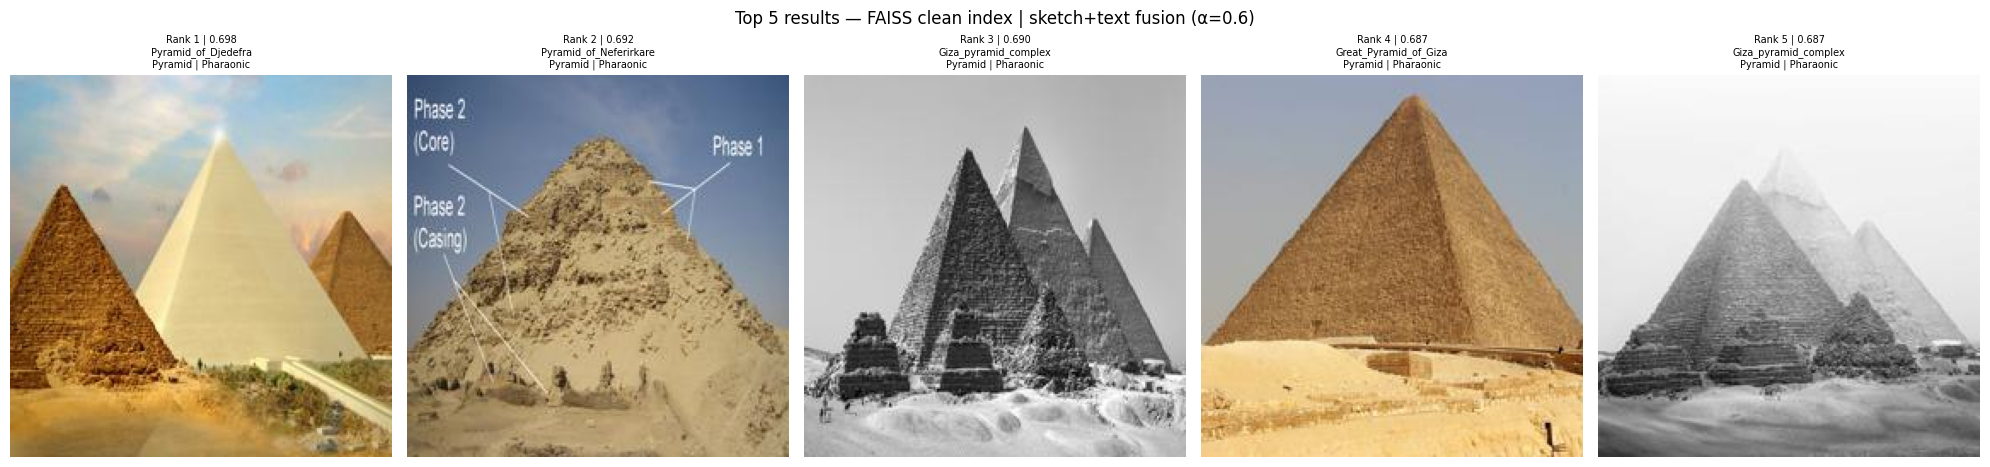

In [26]:
# Display the top results as a visual grid.
# Each image is titled with its rank, score, landmark name, type, and era —
# giving the full picture of what the system retrieved and why.
fig, axes = plt.subplots(1, len(results), figsize=(20, 5))
for i, r in enumerate(results):
    try:
        axes[i].imshow(mpimg.imread(r["image_path"]))
        axes[i].set_title(
            f"Rank {i+1} | {r['score']:.3f}\n"
            f"{r['landmark_name'][:22]}\n"
            f"{r['landmark_type']} | {r['historical_era']}",
            fontsize=7)
        axes[i].axis("off")
    except Exception:
        axes[i].axis("off")

plt.suptitle(
    f"Top {len(results)} results — FAISS clean index | "
    f"sketch+text fusion (α={ALPHA})",
    fontsize=12)
plt.tight_layout()
plt.show()